In [1]:
!pip install onnxruntime pandas numpy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 42.1 MB/s eta 0:00:00


Loading dataset...
Loading ONNX sessions...
Running base models inference...
Running meta-model inference...

 ENSEMBLE EVALUATION RESULTS
ROC-AUC Score: 0.9824

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.97      0.94      0.96    189457
        Rain       0.87      0.93      0.90     78467

    accuracy                           0.94    267924
   macro avg       0.92      0.94      0.93    267924
weighted avg       0.94      0.94      0.94    267924



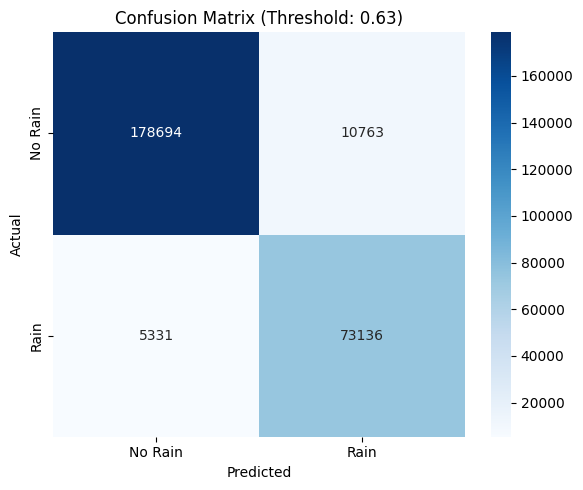

In [4]:
import pandas as pd
import numpy as np
import onnxruntime as rt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


def load_data(csv_path: str):
    print("Loading dataset...")
    df = pd.read_csv(csv_path)
    columns_to_drop = ["Rain", "Timestamp", "Location", "Latitude", "Longitude"]

    # Extract features and target, ensuring float32 for ONNX
    X = df.drop(columns=columns_to_drop, errors="ignore").values.astype(np.float32)
    y = df["Rain"].values.astype(int)
    return X, y


def get_positive_probs(onnx_output):
    """Extract probability of class 1 (Rain) from ONNX output dictionaries."""
    return np.array([row[1] for row in onnx_output])


# Update these paths if you put them inside a specific folder or Google Drive
X, y = load_data("ProcessedHistoric.csv")

print("Loading ONNX sessions...")
sess_xgb = rt.InferenceSession("xgboost_model.onnx", providers=["CPUExecutionProvider"])
sess_lgb = rt.InferenceSession(
    "lightgbm_model.onnx", providers=["CPUExecutionProvider"]
)
sess_cat = rt.InferenceSession(
    "catboost_model.onnx", providers=["CPUExecutionProvider"]
)
sess_meta = rt.InferenceSession("meta_model.onnx", providers=["CPUExecutionProvider"])

print("Running base models inference...")
prob_xgb = get_positive_probs(sess_xgb.run(None, {"input": X})[1])
prob_lgb = get_positive_probs(sess_lgb.run(None, {"input": X})[1])
prob_cat = get_positive_probs(sess_cat.run(None, {"features": X})[1])

print("Running meta-model inference...")
meta_features = np.column_stack((prob_xgb, prob_lgb, prob_cat)).astype(np.float32)
meta_probs = get_positive_probs(sess_meta.run(None, {"meta_input": meta_features})[1])

# The threshold calculated during your MLflow run
best_threshold = 0.630
final_preds = (meta_probs >= best_threshold).astype(int)

print("\n" + "=" * 40)
print(" ENSEMBLE EVALUATION RESULTS")
print("=" * 40)
print(f"ROC-AUC Score: {roc_auc_score(y, meta_probs):.4f}\n")
print("Classification Report:")
print(classification_report(y, final_preds, target_names=["No Rain", "Rain"]))

# Display Confusion Matrix Inline
cm = confusion_matrix(y, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"],
)
plt.title(f"Confusion Matrix (Threshold: {best_threshold})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [2]:
!pip install scikit-learn shap

Loading dataset...
Loading ONNX sessions...

Preparing SHAP Explainer (this may take a moment)...


  0%|          | 0/100 [00:00<?, ?it/s]


 ENSEMBLE SHAP FEATURE IMPORTANCE


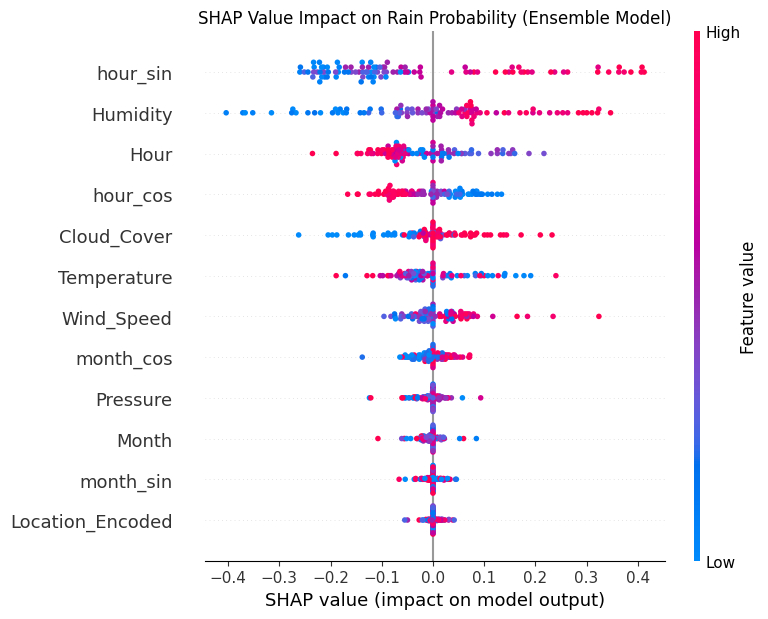

In [6]:
import numpy as np
import onnxruntime as rt
import shap
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


def load_data_and_features(csv_path: str):
    print("Loading dataset...")
    df = pd.read_csv(csv_path)
    columns_to_drop = ["Rain", "Timestamp", "Location", "Latitude", "Longitude"]

    # Extract features, target, and feature names
    feature_names = df.drop(columns=columns_to_drop, errors="ignore").columns.tolist()
    X = df.drop(columns=columns_to_drop, errors="ignore").values.astype(np.float32)

    return X, feature_names


def get_positive_probs(onnx_output):
    """Extract probability of class 1 (Rain) from ONNX output dictionaries."""
    return np.array([row[1] for row in onnx_output])


# 1. Load Data
X, feature_names = load_data_and_features("ProcessedHistoric.csv")

# 2. Load ONNX Sessions
print("Loading ONNX sessions...")
sess_xgb = rt.InferenceSession("xgboost_model.onnx", providers=["CPUExecutionProvider"])
sess_lgb = rt.InferenceSession(
    "lightgbm_model.onnx", providers=["CPUExecutionProvider"]
)
sess_cat = rt.InferenceSession(
    "catboost_model.onnx", providers=["CPUExecutionProvider"]
)
sess_meta = rt.InferenceSession("meta_model.onnx", providers=["CPUExecutionProvider"])


# 3. Create the Black-Box Prediction Wrapper
def ensemble_predict(X_data):
    """Passes data through the 3 base models, then into the meta-model."""
    # Base models
    prob_xgb = get_positive_probs(
        sess_xgb.run(None, {"input": X_data.astype(np.float32)})[1]
    )
    prob_lgb = get_positive_probs(
        sess_lgb.run(None, {"input": X_data.astype(np.float32)})[1]
    )
    prob_cat = get_positive_probs(
        sess_cat.run(None, {"features": X_data.astype(np.float32)})[1]
    )

    # Meta model
    meta_features = np.column_stack((prob_xgb, prob_lgb, prob_cat)).astype(np.float32)
    meta_probs = get_positive_probs(
        sess_meta.run(None, {"meta_input": meta_features})[1]
    )

    return meta_probs


# 4. Initialize SHAP
print("\nPreparing SHAP Explainer (this may take a moment)...")

# Take a random K-means summary of the background data to speed up KernelExplainer
X_background = shap.kmeans(X, 50)

# Select 100 random rows to explain (Increase this number for a denser plot)
np.random.seed(42)
indices_to_explain = np.random.choice(X.shape[0], 100, replace=False)
X_explain = X[indices_to_explain]

# 5. Calculate SHAP Values
explainer = shap.KernelExplainer(ensemble_predict, X_background)
shap_values = explainer.shap_values(
    X_explain, nsamples=500
)  # nsamples controls permutation depth

# 6. Generate the SHAP Summary Plot
print("\n" + "=" * 40)
print(" ENSEMBLE SHAP FEATURE IMPORTANCE")
print("=" * 40)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False)
plt.title("SHAP Value Impact on Rain Probability (Ensemble Model)")
plt.tight_layout()
plt.show()